<a href="https://colab.research.google.com/github/awinarko-hue/Latihan/blob/main/CompVis/CNN_Cifar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN with CIFAR DATASET

sumber : https://www.analyticsvidhya.com/blog/2020/02/learn-image-classification-cnn-convolutional-neural-networks-3-datasets/

CIFAR-10 adalah dataset citra  yang terdiri dari 60.000 gambar ukuran 32x32

terdiri dari 50.000 training dan 10.000 testing

Kita akan mencoba arsitektur CNN sederhana untuk mengelompokan (klasifikasi) gambar menjadi 10 kelas

**Download Dataset**

In [ ]:
from keras.datasets import cifar10
# loading the dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2296s 13us/step


**Import Library**

In [ ]:
# keras imports for the dataset and building our neural network

from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from keras.utils import to_categorical

**Menyiapkan dataset**

In [ ]:
# # building the input vector from the 32x32 pixels
X_train = X_train.reshape(X_train.shape[0], 32, 32, 3)
X_test = X_test.reshape(X_test.shape[0], 32, 32, 3)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# normalizing the data to help with the training
X_train /= 255
X_test /= 255

# one-hot encoding using keras' numpy-related utilities
n_classes = 10
print("Shape before one-hot encoding: ", y_train.shape)
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)
print("Shape after one-hot encoding: ", Y_train.shape)

Shape before one-hot encoding:  (50000, 1)
Shape after one-hot encoding:  (50000, 10)


**Membuat Model**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 75)     │        33,825 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 125)    │        84,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 125)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 125)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │     4,000,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,247,985 (16.20 MB)

 Trainable params: 4,247,985 (16.20 MB)

 Non-trainable params: 0 (0.00 B)

None


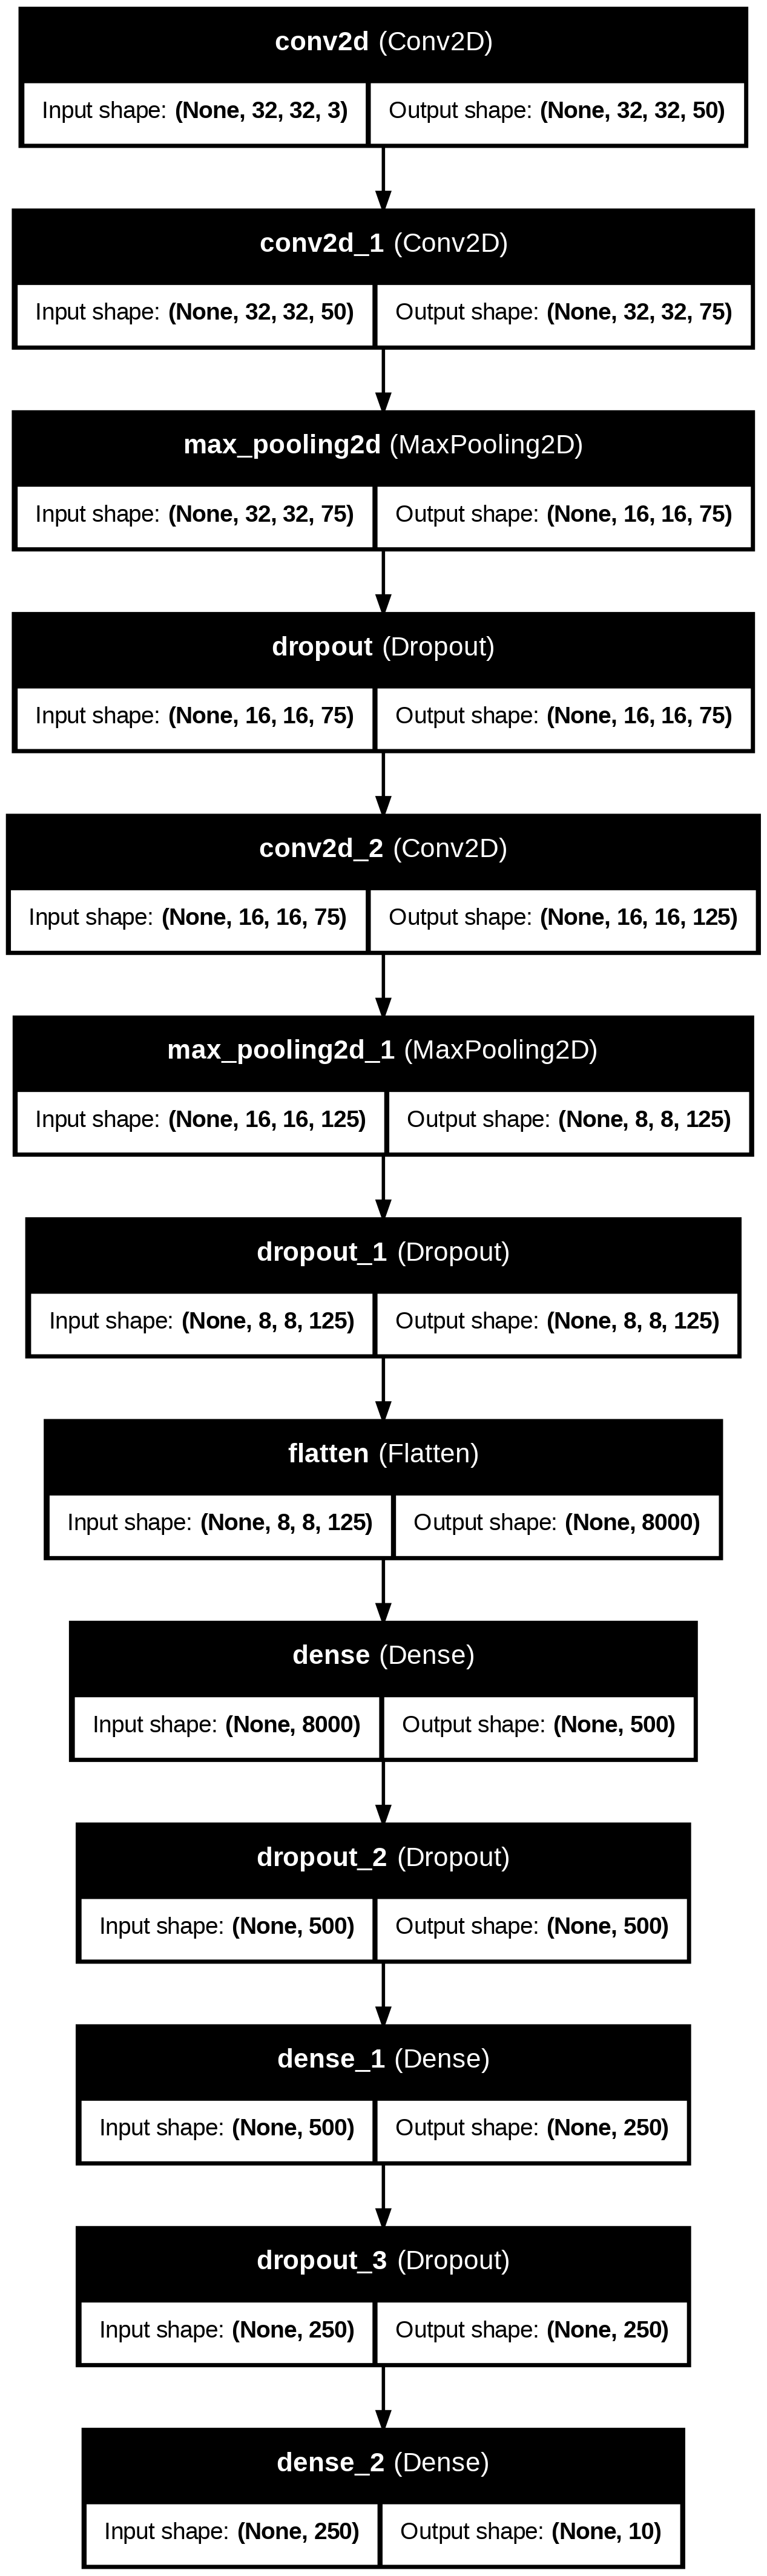

In [ ]:
# building a linear stack of layers with the sequential model
from tensorflow.keras.utils import plot_model
model = Sequential()

# convolutional layer
model.add(Conv2D(50, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu', input_shape=(32, 32, 3)))

# convolutional layer
model.add(Conv2D(75, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(125, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# flatten output of conv
model.add(Flatten())

# hidden layer
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(250, activation='relu'))
model.add(Dropout(0.3))
# output layer
model.add(Dense(10, activation='softmax'))

# compiling the sequential model
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

#menampilkan model
print(model.summary())
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

Model yang dibangun terdiri dari beberapa layer dan dengan jumlah parameter pada masing masing  layer misal untuk layer 1, adalah layer konvolusi 2 dimensi dengan keluaran 32 x 32 x 50.

Jika kita lihat pada saat pembangunan model untuk layer 1



```
model.add(Conv2D(50, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu', input_shape=(32, 32, 3)))
```
Jadi di layer ini ada konvolusi 2 dimensi dengan kernek sebanyak 50, masing masing kernel berukuran 3 x 3 dengan stride (lompatan) kernel pada saat konvolusi adalah 1 ke kanan 1 ke bawah (1,1) padding nya same artinya ukuran masukan dan ukuran keluaran sama (32x32) masukannya adalah image 32x32x3 (ukurapn lebar 32, tinggi 32 terdapat 3 sinyal warna R,G dan B)
Jumlah parameter = 1400 berasal dari ((3 x 3 x 3)+1) x 50 = 28 x 50 = 1400
3 x 3 ukuran kernel, x 3 karena butuh 3 lapis untuk tiap kernel untuk dikonvolusi dengan lapisan gambar R,G,B di tambah 1 karena untuk setiap konvolusi ada 1 nilai bias yang ditambahkan.






**Melakukan Training dan Validasi**

In [ ]:
history = model.fit(X_train, Y_train, batch_size=128, epochs=15, validation_data=(X_test, Y_test))

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 555s 1s/step - accuracy: 0.8399 - loss: 0.4547 - val_accuracy: 0.7841 - val_loss: 0.6330
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 573s 1s/step - accuracy: 0.8475 - loss: 0.4272 - val_accuracy: 0.7792 - val_loss: 0.6727
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 558s 1s/step - accuracy: 0.8543 - loss: 0.4087 - val_accuracy: 0.7812 - val_loss: 0.6642
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 564s 1s/step - accuracy: 0.8652 - loss: 0.3792 - val_accuracy: 0.7874 - val_loss: 0.6614
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 539s 1s/step - accuracy: 0.8715 - loss: 0.3611 - val_accuracy: 0.7882 - val_loss: 0.6578
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 568s 1s/step - accuracy: 0.8760 - loss: 0.3483 - val_accuracy: 0.7909 - val_loss: 0.6619
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 559s 1s/step - accuracy: 0.8829 - loss: 0.3329 - val_accuracy: 0.7873 - val_loss: 0.6809
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 563s 1s/step - accuracy: 0.8866 - loss: 0.3203 - val_accu

Dengan 10 epoch (iterasi) didapati model dengan akurasi training 84.25% dan akurasi validasi terbaik 78.11%

additional explanation
https://towardsdatascience.com/understanding-and-calculating-the-number-of-parameters-in-convolution-neural-networks-cnns-fc88790d530d

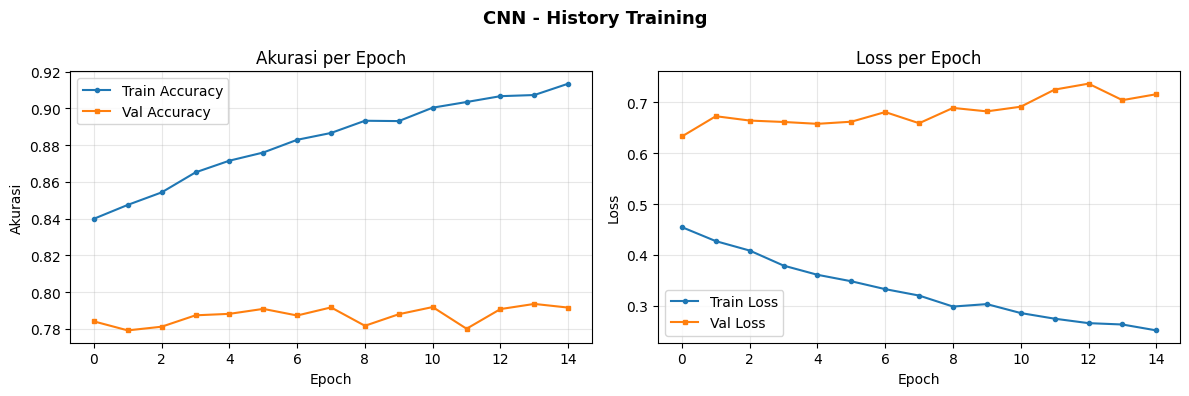

In [ ]:
# ─────────────────────────────────────────────────────────────────
# VISUALISASI TRAINING HISTORY
# ─────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CNN - History Training', fontsize=13, fontweight='bold')

epochs_ran = len(history.history['accuracy'])

ax1.plot(history.history['accuracy'],     label='Train Accuracy', marker='o', markersize=3)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   marker='s', markersize=3)
ax1.set_title('Akurasi per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Akurasi')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'],     label='Train Loss', marker='o', markersize=3)
ax2.plot(history.history['val_loss'], label='Val Loss',   marker='s', markersize=3)
ax2.set_title('Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=120, bbox_inches='tight')
plt.show()